# Diagnóstico de SOP (Síndrome dos Ovários Policísticos) — PCOS
**Dataset:** PCOS Without Infertility ([Kaggle](https://www.kaggle.com/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos))

**Objetivo:** Construir e comparar modelos de classificação para prever a presença de SOP com base em dados clínicos e laboratoriais.

**Estrutura do notebook:**
1. Importações
2. Carregamento dos dados
3. Análise exploratória (EDA)
4. Pré-processamento e pipeline
5. Comparação de modelos (todas as features)
6. Análise de overfitting
7. Curva ROC comparativa
8. Seleção das Top 20 features
9. Explicabilidade com SHAP


## 1. Importações

In [ ]:
# Todas as importações centralizadas para facilitar manutenção e evitar redundâncias
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import shap

import kagglehub

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Exibe todas as colunas do DataFrame ao imprimir
pd.set_option('display.max_columns', None)


## 2. Funções auxiliares

In [ ]:
def avaliar_modelo_classificacao(y_real, y_pred, y_proba, nome="Modelo"):
    """
    Imprime métricas completas de classificação e exibe a matriz de confusão.

    Parâmetros
    ----------
    y_real  : array-like — rótulos verdadeiros
    y_pred  : array-like — predições do modelo
    y_proba : array-like — probabilidades da classe positiva
    nome    : str        — identificador do modelo (usado no título)
    """
    print(f"\n{'─' * 40}")
    print(f"  {nome}")
    print(f"{'─' * 40}")
    print(classification_report(y_real, y_pred))
    print(f"AUC-ROC: {roc_auc_score(y_real, y_proba):.4f}")
    ConfusionMatrixDisplay.from_predictions(y_real, y_pred)
    plt.title(nome)
    plt.tight_layout()
    plt.show()


def comparar_modelos(modelos, pipeline_base, X_tr, y_tr):
    scoring = {
        "roc_auc":  "roc_auc",
        "f1":       "f1",
        "precision":"precision",
        "recall":   "recall",
        "accuracy": "accuracy",
    }
    resultados = {}

    for nome, modelo in modelos.items():
        pipe = Pipeline([
            ('preprocessor', pipeline_base),
            ('model', modelo),
        ])

        cv = cross_validate(
            pipe,
            X_tr,
            y_tr,
            cv=5,
            scoring=scoring,
            return_train_score=True
        )

        train_auc = cv['train_roc_auc'].mean()
        val_auc   = cv['test_roc_auc'].mean()
        gap       = train_auc - val_auc
        flag      = '🔴' if gap > 0.10 else ('🟡' if gap > 0.05 else '🟢')

        resultados[nome] = {
            'roc_auc':   val_auc,
            'f1':        cv['test_f1'].mean(),
            'precision': cv['test_precision'].mean(),
            'recall':    cv['test_recall'].mean(),
            'accuracy':  cv['test_accuracy'].mean(),
            'train_auc': train_auc,
            'gap':       gap,
            'flag':      flag,
        }

        print(f"\n📊 {nome}")
        print(f"  ROC AUC (val):   {val_auc:.4f}")
        print(f"  ROC AUC (train): {train_auc:.4f}")
        print(f"  Gap overfitting: {gap:.4f}  {flag}")
        print(f"  Recall:          {resultados[nome]['recall']:.4f}")
        print(f"  F1-score:        {resultados[nome]['f1']:.4f}")
        print(f"  Precision:       {resultados[nome]['precision']:.4f}")
        print(f"  Accuracy:        {resultados[nome]['accuracy']:.4f}")

    return resultados


## 3. Carregamento dos dados

In [ ]:
# Download automático do dataset via KaggleHub
path = kagglehub.dataset_download(
    "prasoonkottarathil/polycystic-ovary-syndrome-pcos"
)

df = pd.read_excel(
    os.path.join(path, "PCOS_data_without_infertility.xlsx"),
    sheet_name="Full_new"
)

print(f"Shape: {df.shape}")
df.head()


Using Colab cache for faster access to the 'polycystic-ovary-syndrome-pcos' dataset.
Shape: (541, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,3.415254,42,36,0.857143,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,4.422222,37,30,0.810811,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


## 4. Análise exploratória (EDA)

### 4.1 Visão geral do dataset

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

### 4.2 Valores nulos e limpeza
O heatmap abaixo é gerado **antes** do tratamento dos nulos para identificar as colunas afetadas.


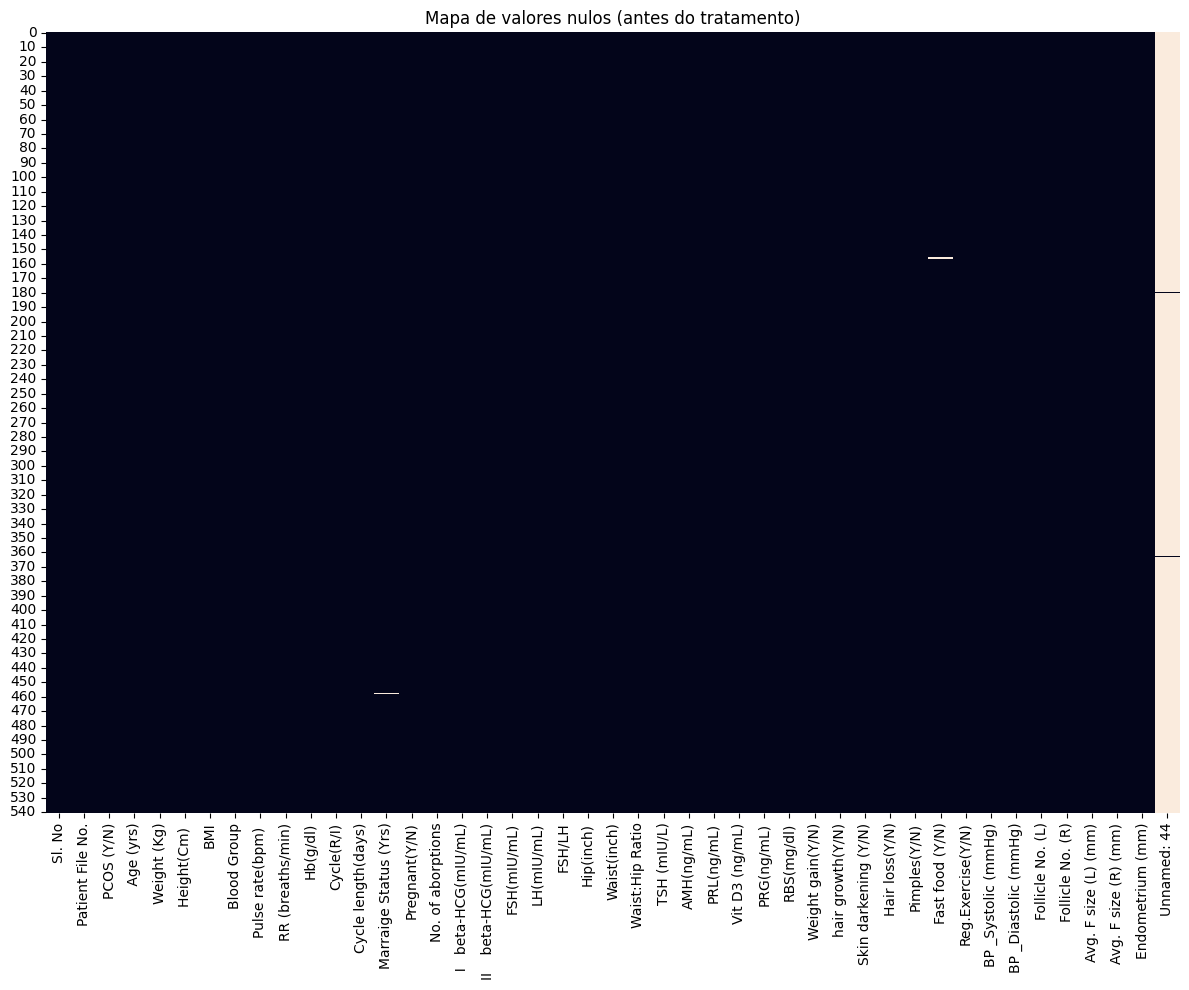

In [ ]:
# Heatmap de valores nulos — identifica padrão de missingness
plt.figure(figsize=(12, 10))
sns.heatmap(df.isnull(), cbar=False)
plt.title('Mapa de valores nulos (antes do tratamento)')
plt.tight_layout()
plt.show()




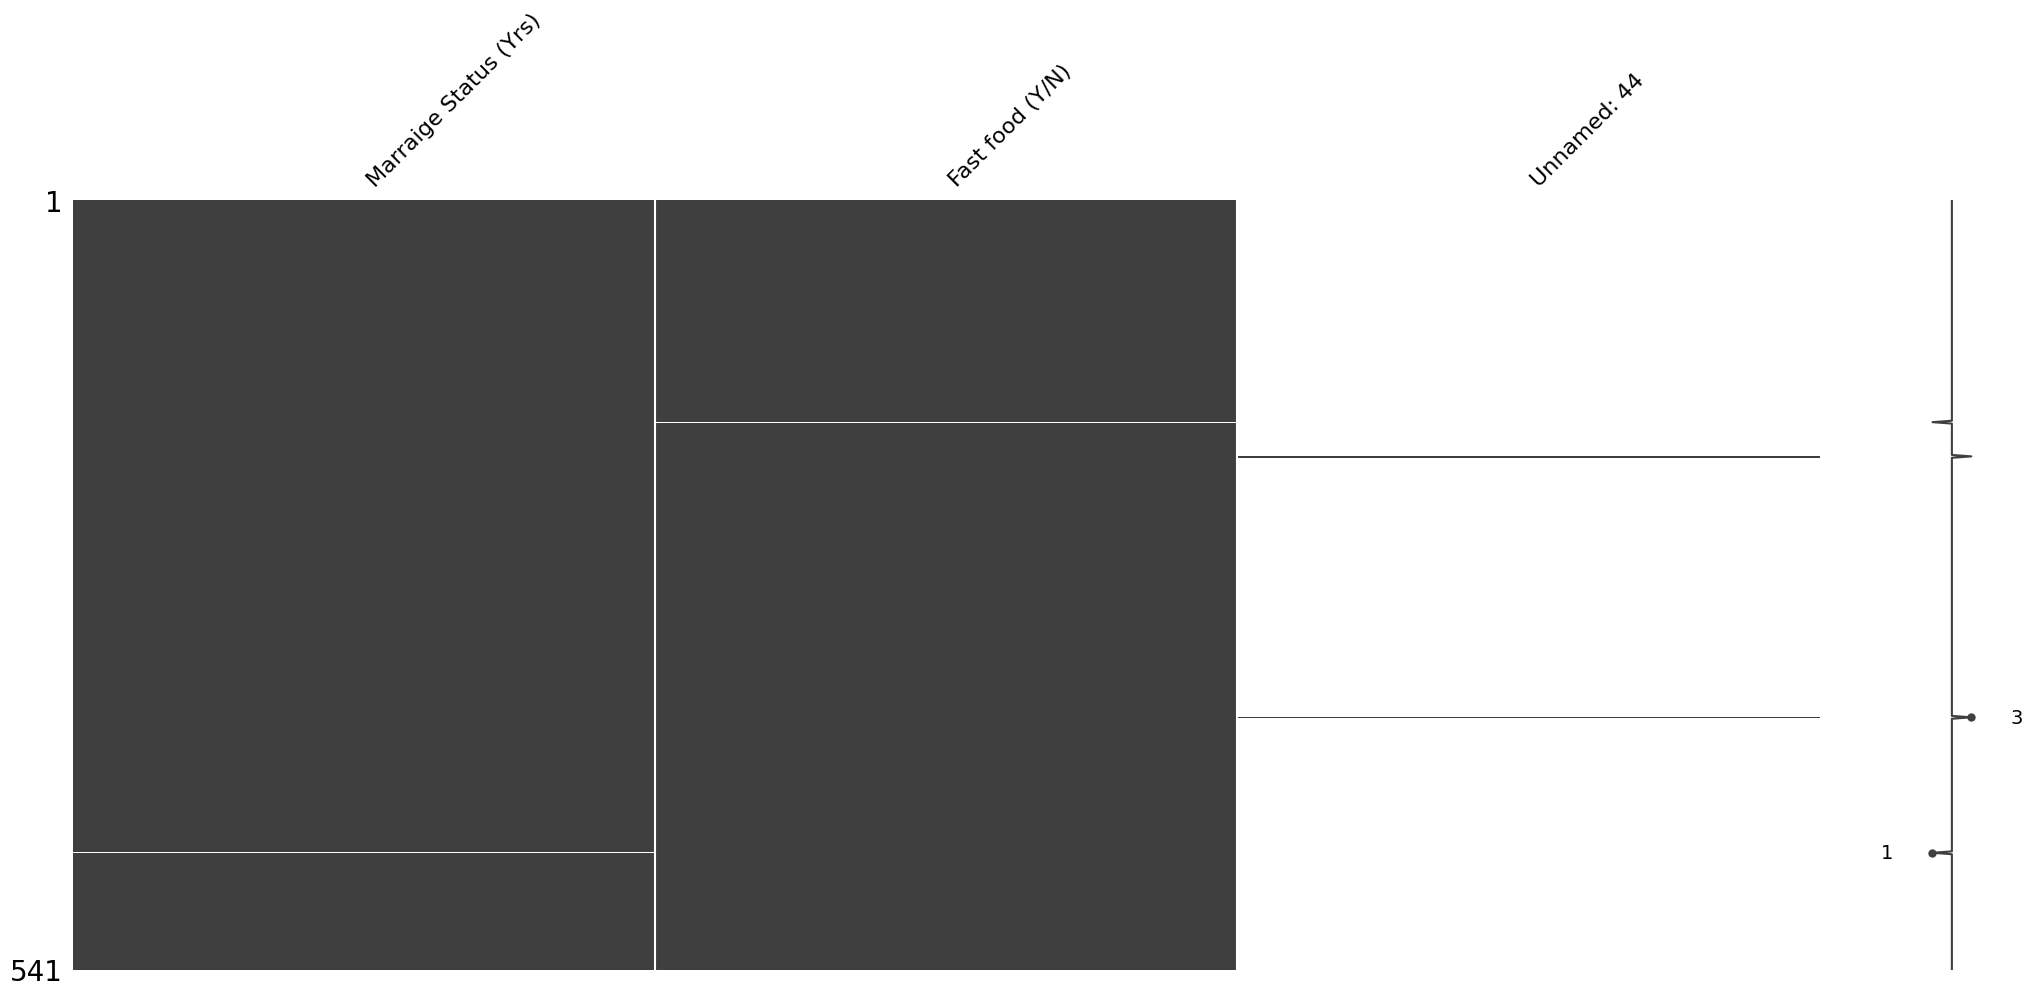

In [ ]:
# Complemento: gráfico de completude por coluna (apenas colunas com missing)
msno.matrix(df.loc[:, df.isnull().any()])
plt.show()

### 4.3 Tratamento de colunas problemáticas

**`Unnamed: 44`** — coluna sem padrão identificável, provavelmente um artefato da exportação do Excel. Removida.

**`Marraige Status (Yrs)`** — variável numérica inteira; valores faltantes preenchidos com a **média** (distribuição contínua).

**`Fast food (Y/N)`** — variável binária; valores faltantes preenchidos com a **moda** para preservar a distribuição original.

**`II beta-HCG(mIU/mL)` e `AMH(ng/mL)`** — colunas lidas como `object` por conterem um valor corrompido. Convertidas com `pd.to_numeric` e nulos preenchidos com a **mediana** (robusta a outliers).

**`Sl. No` e `Patient File No.`** — identificadores sem valor preditivo. Removidos.


In [ ]:
# Remove coluna suja sem padrão identificável
df.drop(columns=['Unnamed: 44'], inplace=True)

# Marraige Status — preenche nulos com a média (valor contínuo)
media_casamento = df['Marraige Status (Yrs)'].mean()
df['Marraige Status (Yrs)'].fillna(media_casamento, inplace=True)

# Fast food — preenche nulos com a moda (variável binária)
moda_fastfood = int(df['Fast food (Y/N)'].mode()[0])
df['Fast food (Y/N)'].fillna(moda_fastfood, inplace=True)

# Converte colunas numéricas corrompidas e preenche com mediana
for col in ['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].median(), inplace=True)

# Remove identificadores
df.drop(columns=['Sl. No', 'Patient File No.'], inplace=True)

# Confirma que não restam nulos
print(f"Nulos restantes: {df.isnull().sum().sum()}")
df.info()


Nulos restantes: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PCOS (Y/N)              541 non-null    int64  
 1    Age (yrs)              541 non-null    int64  
 2   Weight (Kg)             541 non-null    float64
 3   Height(Cm)              541 non-null    float64
 4   BMI                     541 non-null    float64
 5   Blood Group             541 non-null    int64  
 6   Pulse rate(bpm)         541 non-null    int64  
 7   RR (breaths/min)        541 non-null    int64  
 8   Hb(g/dl)                541 non-null    float64
 9   Cycle(R/I)              541 non-null    int64  
 10  Cycle length(days)      541 non-null    int64  
 11  Marraige Status (Yrs)   541 non-null    float64
 12  Pregnant(Y/N)           541 non-null    int64  
 13  No. of aborptions       541 non-null    int64  
 14    I   beta-HCG(mIU/mL) 

/tmp/ipykernel_3203/2180125966.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Marraige Status (Yrs)'].fillna(media_casamento, inplace=True)
/tmp/ipykernel_3203/2180125966.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

### 4.4 Codificação de variáveis categóricas
O campo `Blood Group` é uma variável categórica nominal (tipo sanguíneo),
não ordinal. Aplicamos **dummy encoding** (`get_dummies`) com `drop_first=True`
para evitar multicolinearidade perfeita.


In [ ]:
df = pd.get_dummies(df, columns=['Blood Group'], drop_first=True, dtype=int)
print(f"Shape após dummies: {df.shape}")
df.head()


Shape após dummies: (541, 48)


,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Blood Group_12,Blood Group_13,Blood Group_14,Blood Group_15,Blood Group_16,Blood Group_17,Blood Group_18
0,0,28,44.6,152.0,19.300000,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,0,0,0,1,0,0,0
1,0,36,65.0,161.5,24.921163,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,0,0,0,1,0,0,0
2,1,33,68.8,165.0,25.270891,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,0,0,0,0,0,0,0
3,0,37,65.0,148.0,29.674945,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,3.415254,42,36,0.857143,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,0,1,0,0,0,0,0
4,0,25,52.0,161.0,20.060954,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,4.422222,37,30,0.810811,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,0,0,0,0,0,0,0


### 4.5 Distribuição do target (PCOS)

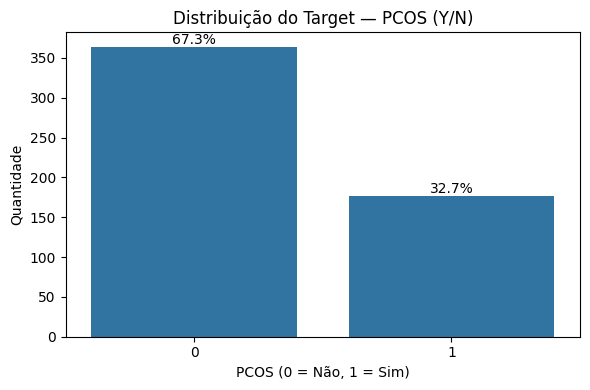

PCOS (Y/N)
Não    0.672828
Sim    0.327172
Name: proportion, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='PCOS (Y/N)', data=df, ax=ax)

total = len(df)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f'{pct:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

ax.set_title('Distribuição do Target — PCOS (Y/N)')
ax.set_ylabel('Quantidade')
ax.set_xlabel('PCOS (0 = Não, 1 = Sim)')
plt.tight_layout()
plt.show()

print(df['PCOS (Y/N)'].value_counts(normalize=True).rename({0: 'Não', 1: 'Sim'}))


### 4.6 Correlação das features com o target

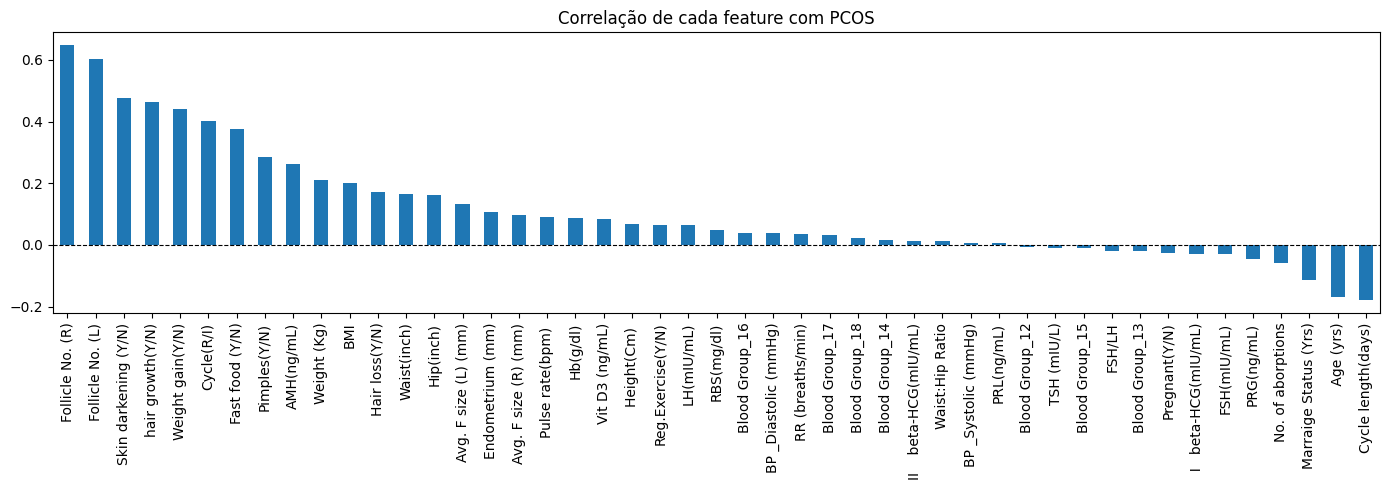

In [ ]:
# Correlação de Pearson de cada feature com o target
corr_target = df.corr(numeric_only=True)['PCOS (Y/N)'].sort_values(ascending=False)

corr_target.drop('PCOS (Y/N)').plot(kind='bar', figsize=(14, 5))
plt.title('Correlação de cada feature com PCOS')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()


### 4.7 Boxplot + Violin: Top 20 features × PCOS

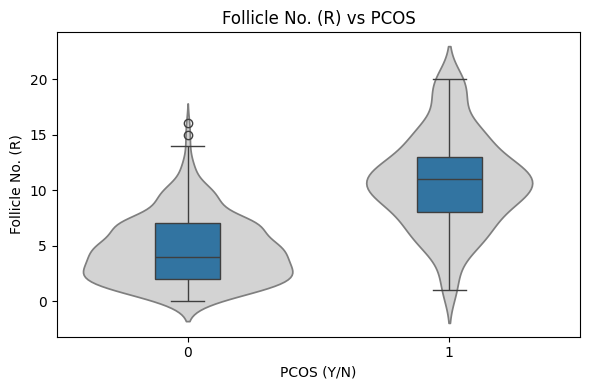

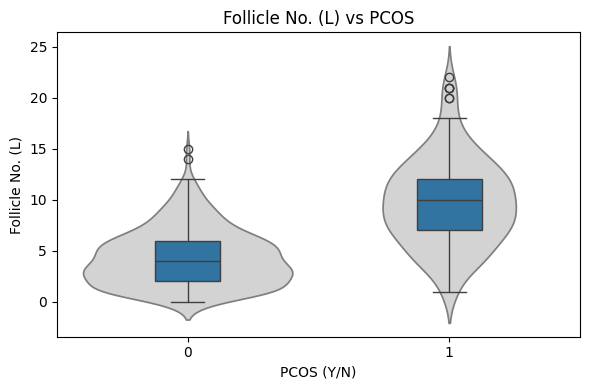

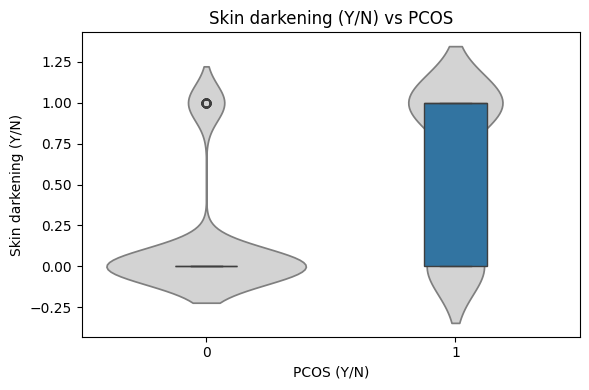

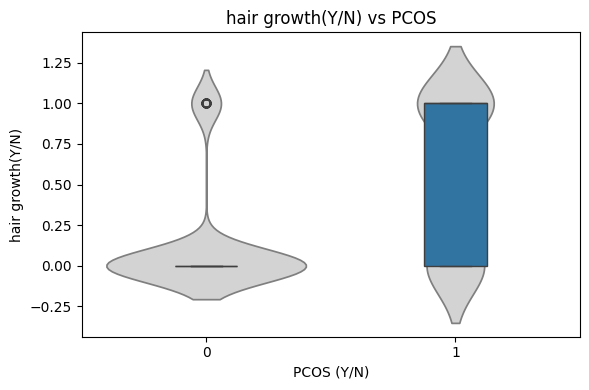

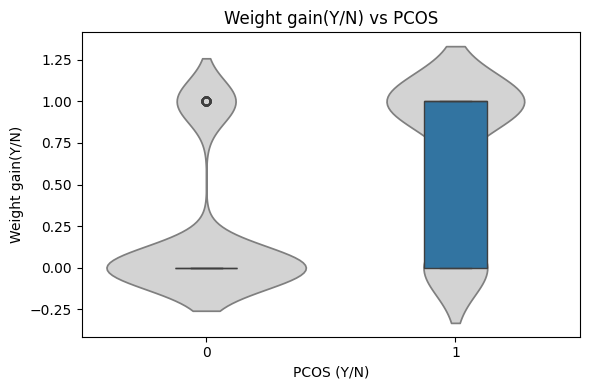

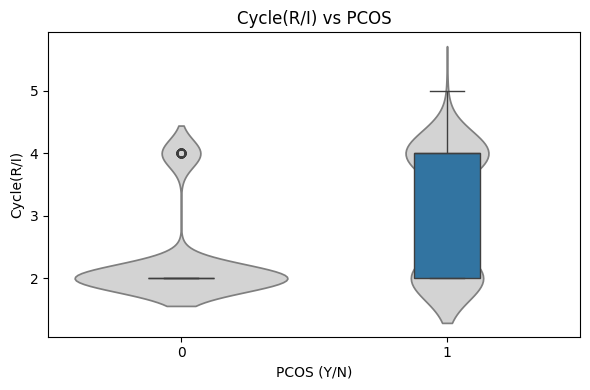

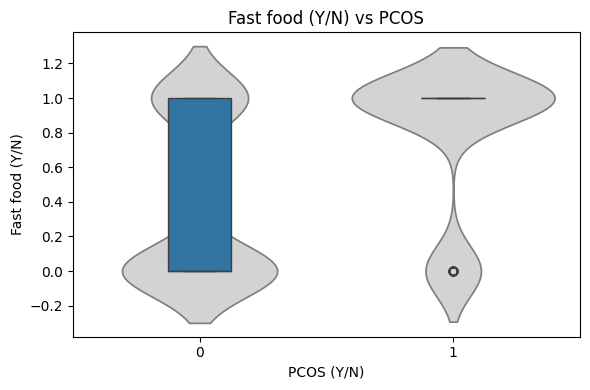

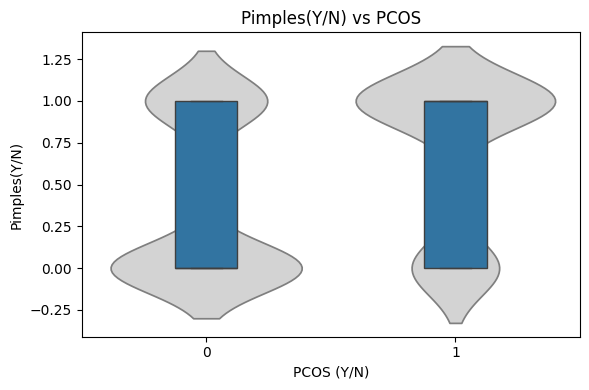

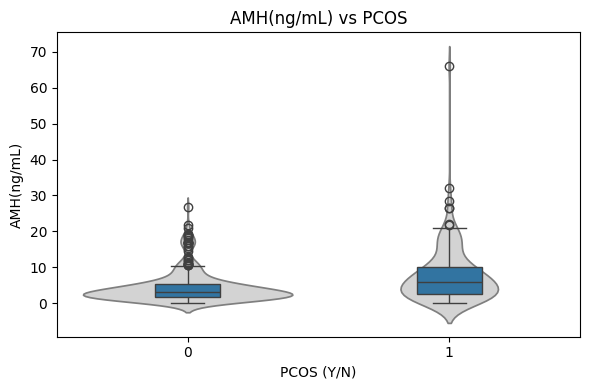

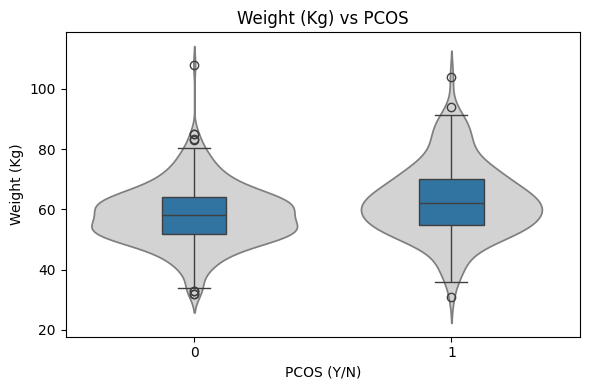

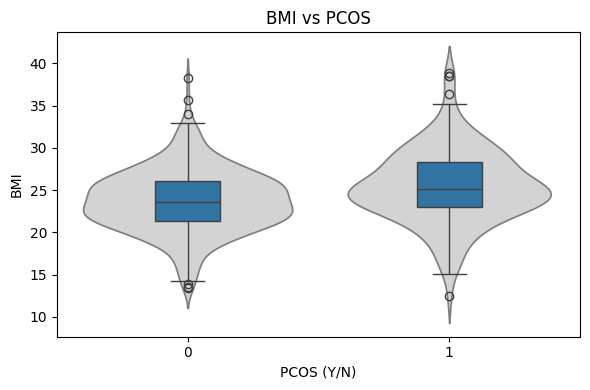

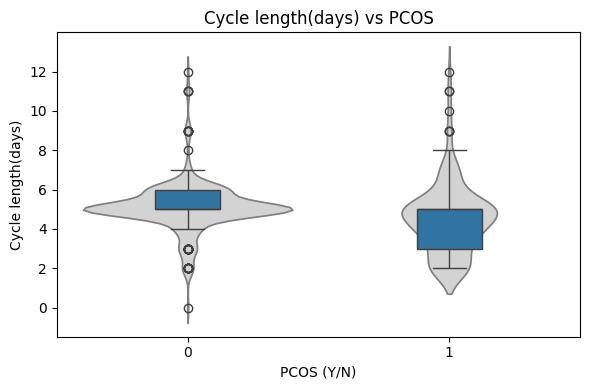

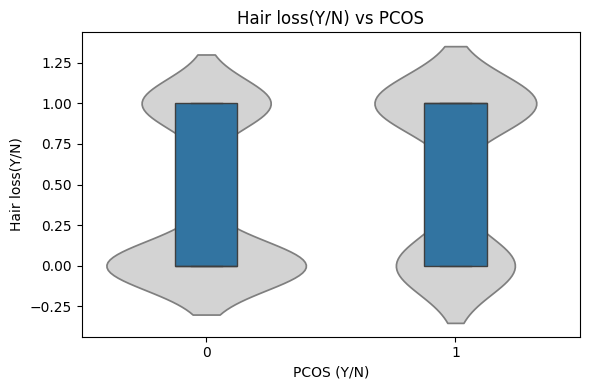

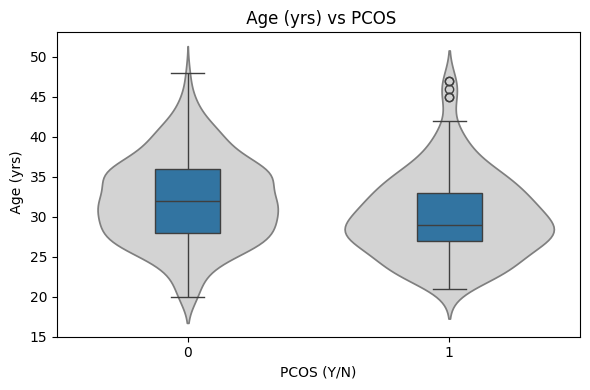

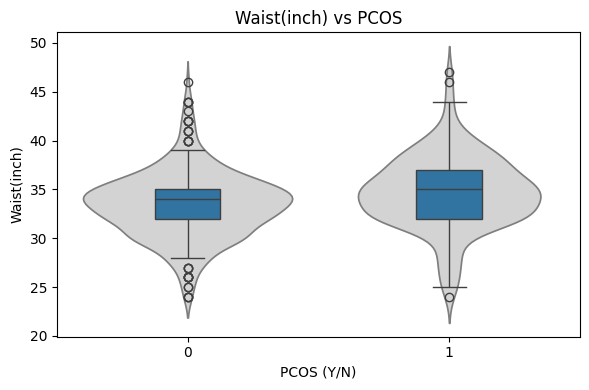

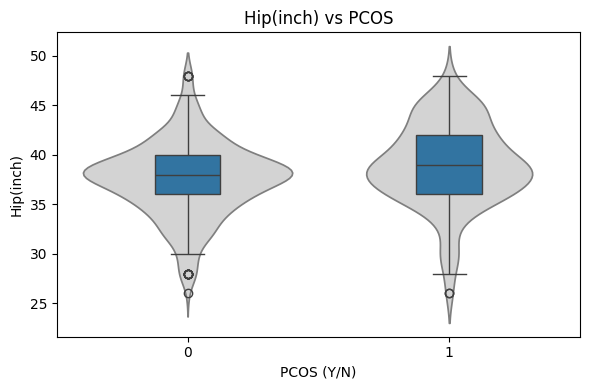

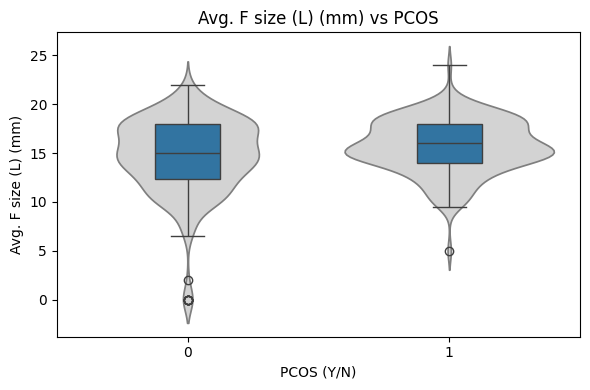

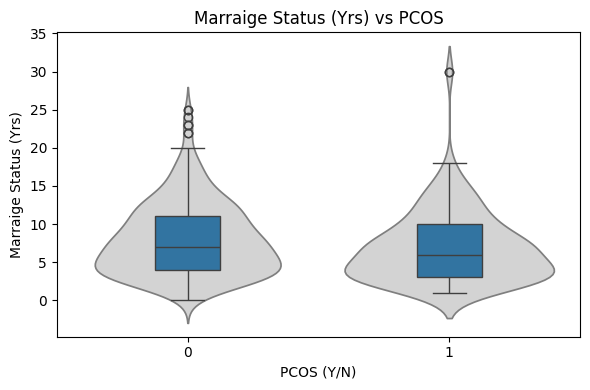

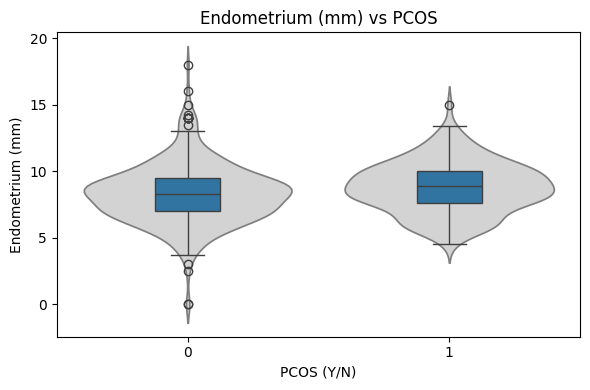

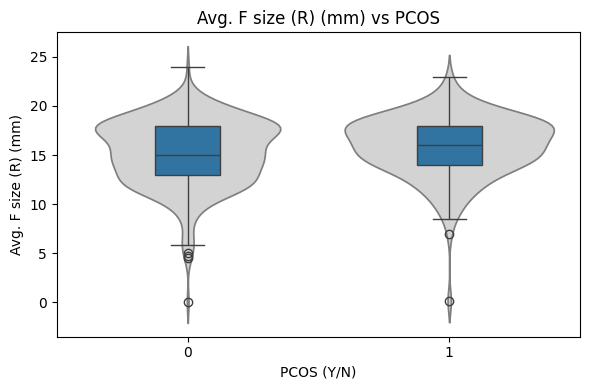

In [ ]:
# Seleciona as 20 features com maior correlação absoluta com o target
corr_abs = corr_target.abs().drop('PCOS (Y/N)').sort_values(ascending=False)
top20_features_eda = corr_abs.head(20).index

for col in top20_features_eda:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.violinplot(x='PCOS (Y/N)', y=col, data=df, inner=None,
                   color='lightgray', ax=ax)
    sns.boxplot(x='PCOS (Y/N)', y=col, data=df, width=0.25, ax=ax)
    ax.set_title(f'{col} vs PCOS')
    plt.tight_layout()
    plt.show()


### 4.8 Histogramas por classe: Top 20 features

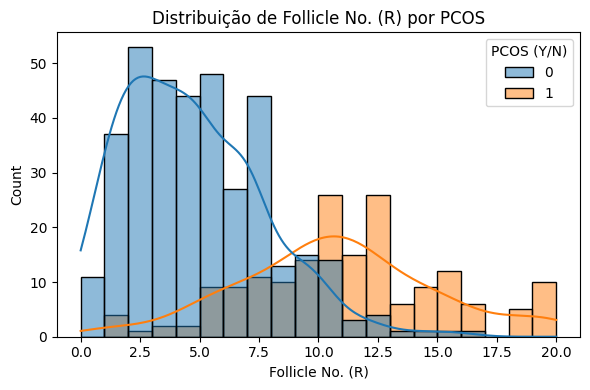

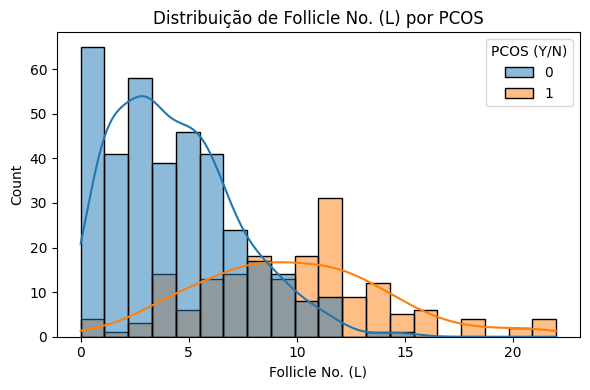

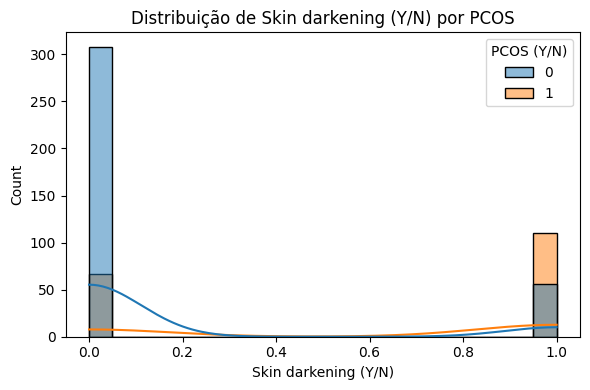

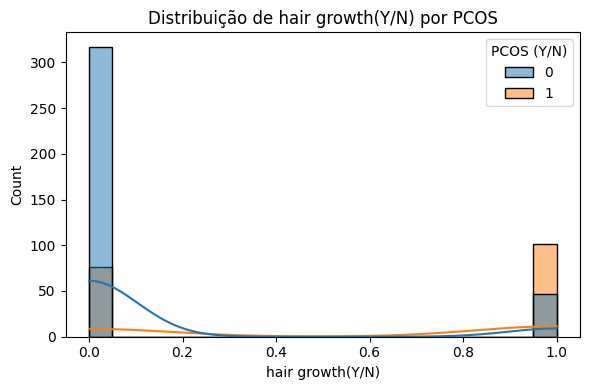

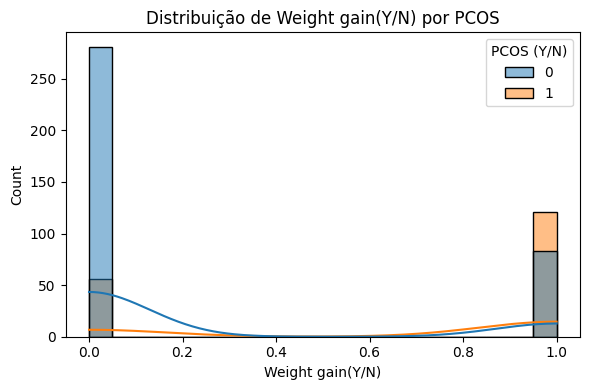

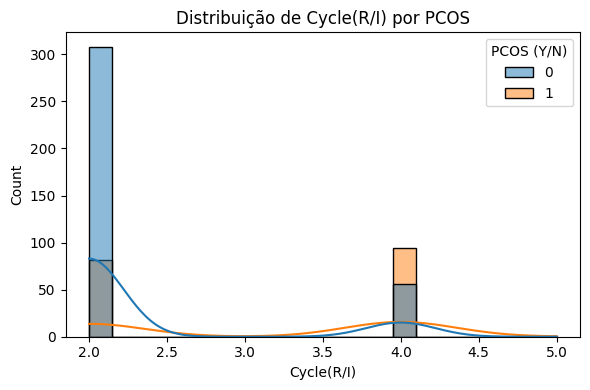

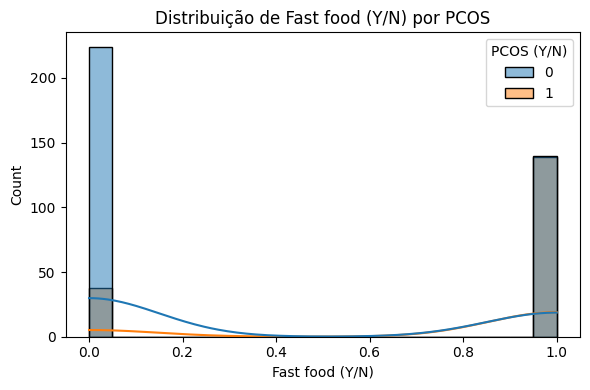

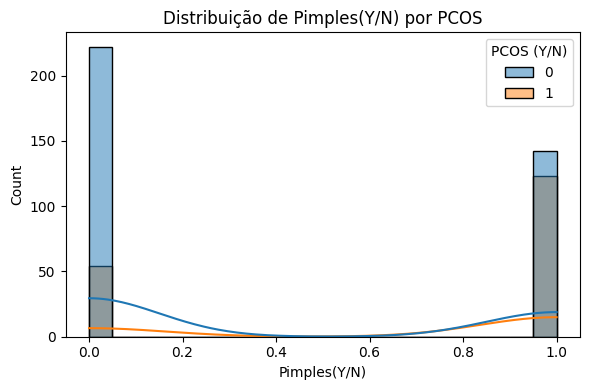

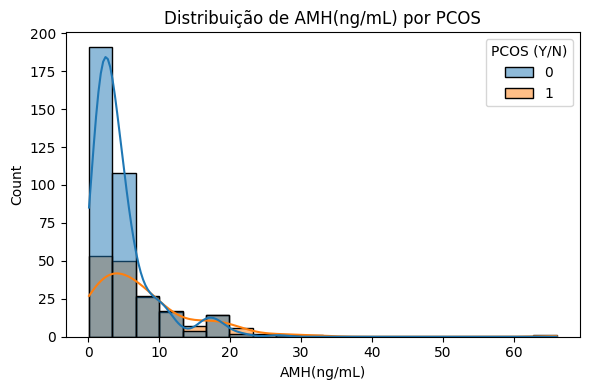

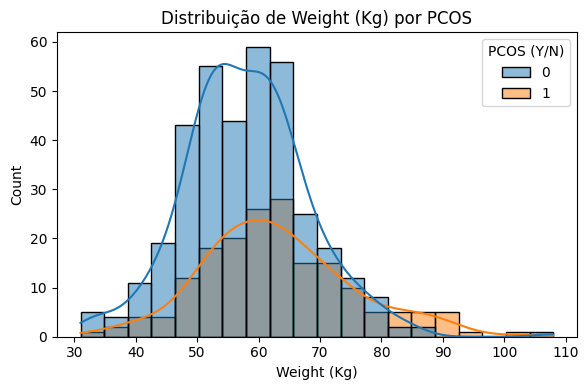

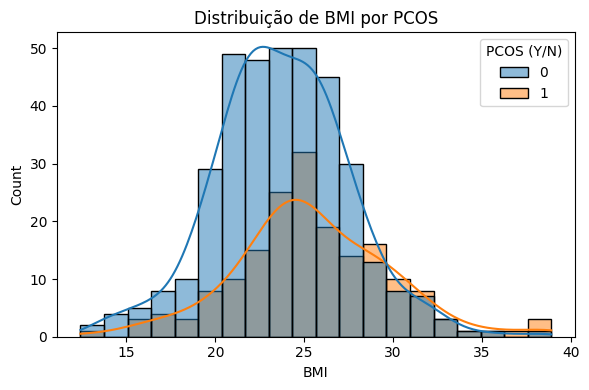

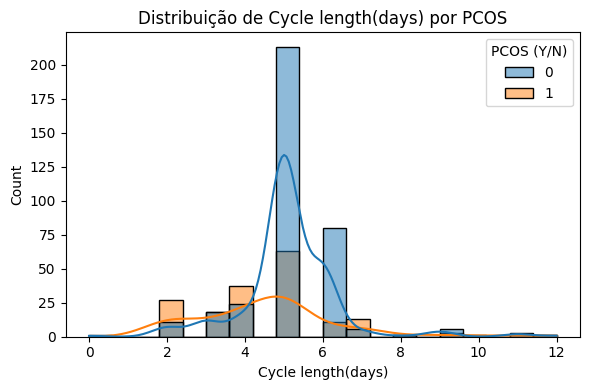

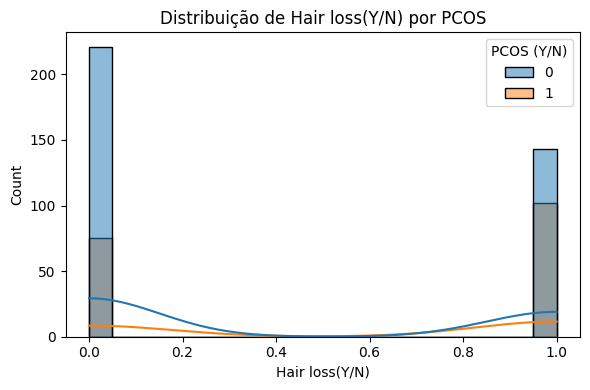

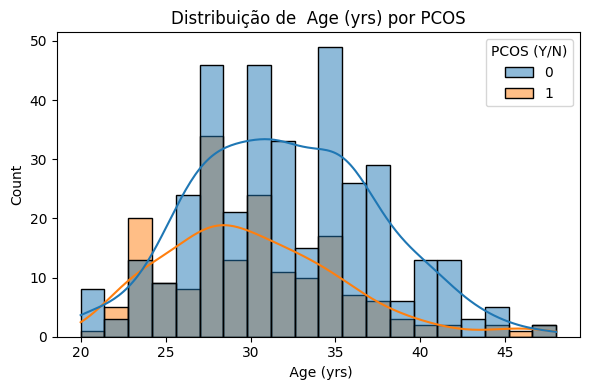

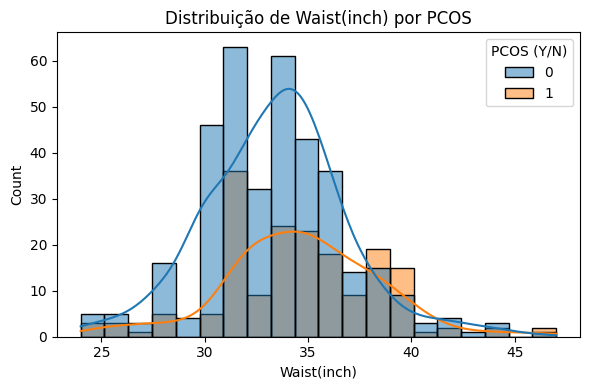

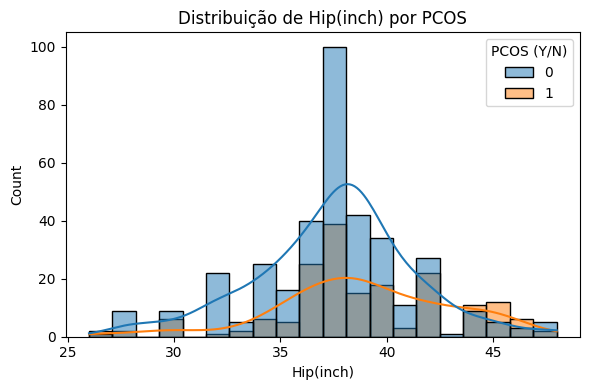

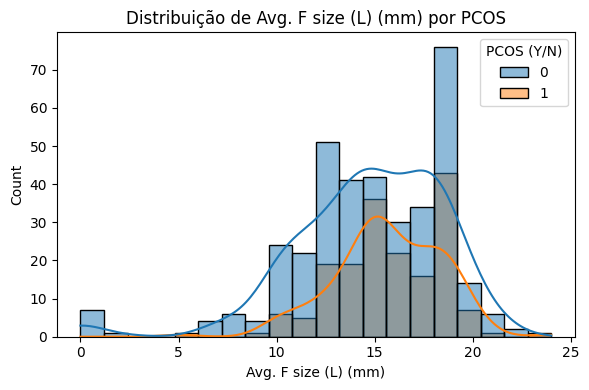

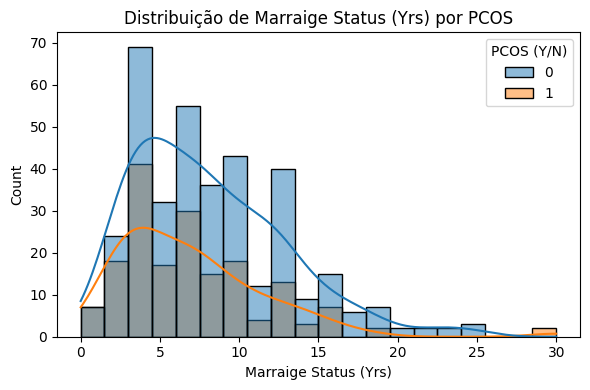

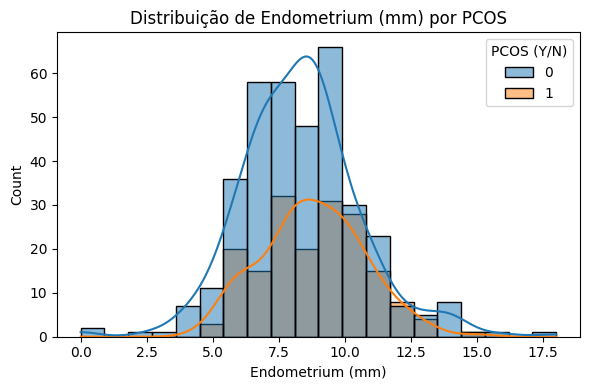

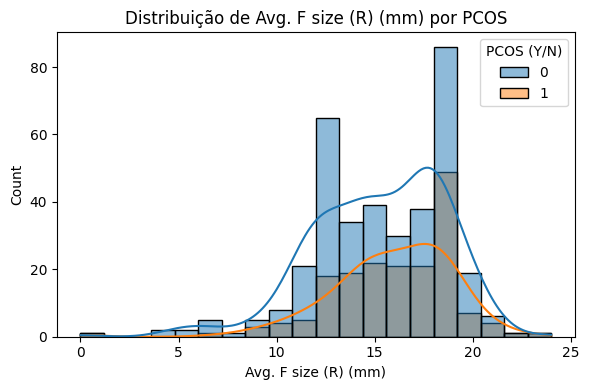

In [ ]:
for col in top20_features_eda:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, hue='PCOS (Y/N)', bins=20, kde=True)
    plt.title(f'Distribuição de {col} por PCOS')
    plt.tight_layout()
    plt.show()


### 4.9 Matriz de correlação geral

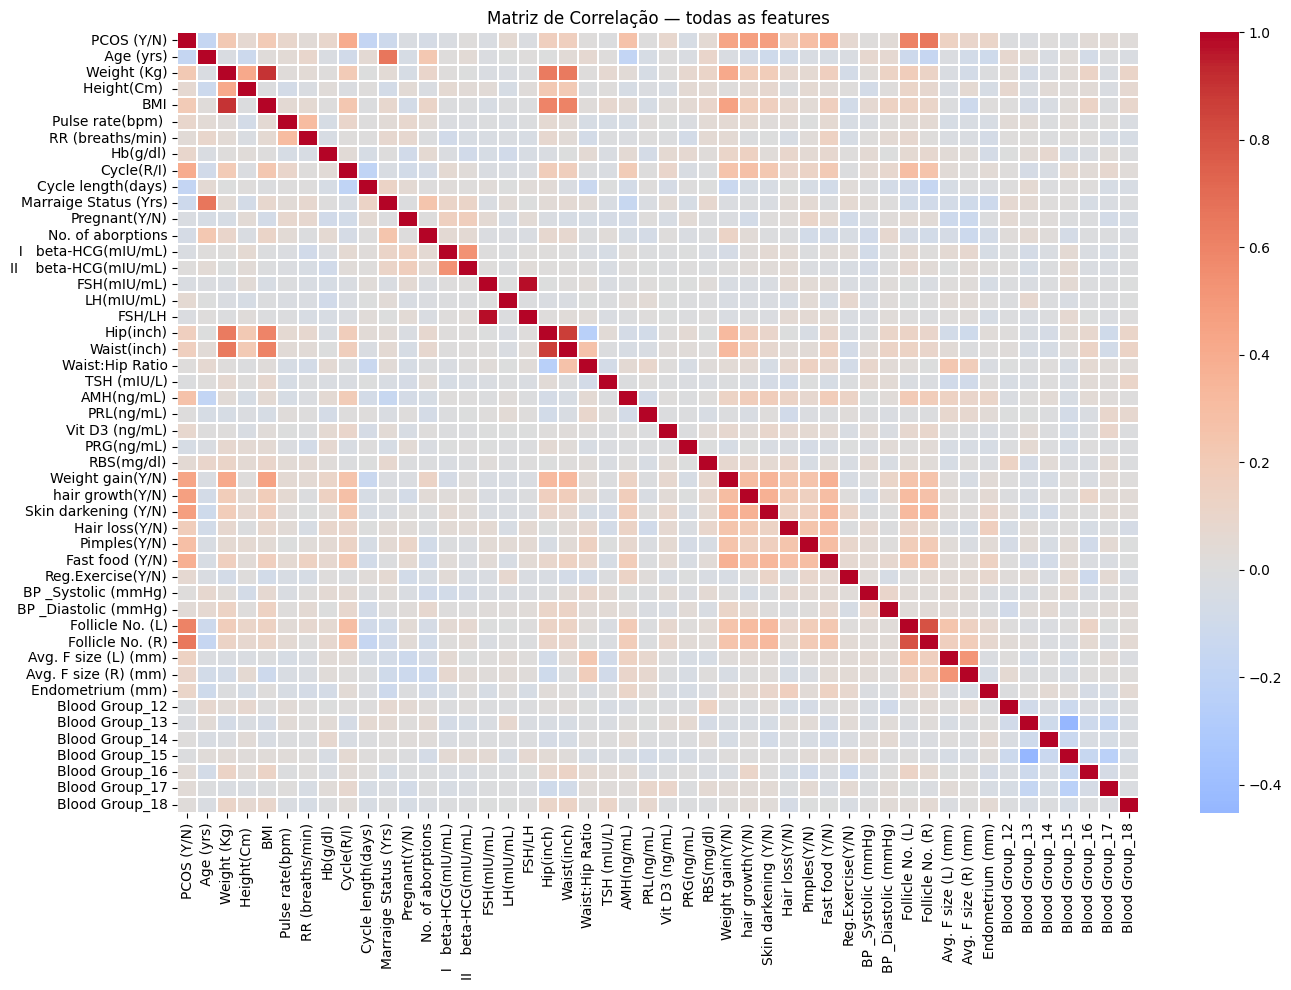

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0,
            linewidths=0.3, annot=False)
plt.title('Matriz de Correlação — todas as features')
plt.tight_layout()
plt.show()


### 4.10 Pares de features altamente correlacionadas (multicolinearidade)
Features com correlação > 0.8 entre si podem ser redundantes e introduzir
instabilidade em modelos lineares. Identificamos e removemos as mais óbvias.


In [ ]:
# Identificar pares com |correlação| > 0.8 (excluindo autocorrelação)
corr_matrix = df.corr(numeric_only=True).copy()
np.fill_diagonal(corr_matrix.values, 0)

corr_pairs = (corr_matrix.abs()
              .unstack()
              .drop_duplicates()
              .sort_values(ascending=False))

THRESHOLD = 0.8
high_corr = corr_pairs[corr_pairs > THRESHOLD]

print(f"Pares com |correlação| > {THRESHOLD}:")
for (c1, c2), val in high_corr.items():
    print(f"  {c1}  ×  {c2}:  {val:.2f}")


Pares com |correlação| > 0.8:
  FSH(mIU/mL)  ×  FSH/LH:  0.97
  Weight (Kg)  ×  BMI:  0.90
  Hip(inch)  ×  Waist(inch):  0.87


In [ ]:
# Remoção das features redundantes identificadas acima:
#   - 'Weight (Kg)' e 'Waist(inch)': substituídas pelo IMC (BMI) já presente
#   - 'FSH(mIU/mL)': altamente correlacionada com FSH/LH (que é calculada a partir dela)
df.drop(columns=['Weight (Kg)', 'FSH(mIU/mL)', 'Waist(inch)'], inplace=True)

print(f"Shape final após remoção: {df.shape}")


Shape final após remoção: (541, 45)


## 5. Pré-processamento e Pipeline

Separamos as features em dois grupos para tratamentos distintos:

- **Numéricas contínuas** → imputação pela mediana + normalização (StandardScaler)
- **Binárias (0/1)** → passadas sem transformação (`passthrough`)

Usamos `ColumnTransformer` + `Pipeline` do scikit-learn para garantir que
o `fit` acontece **somente nos dados de treino**, eliminando data leakage.


In [ ]:
# Colunas binárias (flags e dummies de tipo sanguíneo)
binary_cols = [
    'Pregnant(Y/N)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
    'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
    'Fast food (Y/N)', 'Reg.Exercise(Y/N)',
    'Blood Group_12', 'Blood Group_13', 'Blood Group_14',
    'Blood Group_15', 'Blood Group_16', 'Blood Group_17', 'Blood Group_18',
]

# Colunas numéricas contínuas (tudo que não é target nem binário)
num_cols = [
    col for col in df.drop(columns=['PCOS (Y/N)']).select_dtypes(include=np.number).columns
    if col not in binary_cols
]

# Pipeline para numéricas: mediana → normalização z-score
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Pipeline completo: transforma numéricas e passa binárias sem alteração
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('bin', 'passthrough', binary_cols),
])

print(f"Features numéricas ({len(num_cols)}): {num_cols}")
print(f"\nFeatures binárias ({len(binary_cols)}): {binary_cols}")


Features numéricas (29): [' Age (yrs)', 'Height(Cm) ', 'BMI', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'No. of aborptions', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']

Features binárias (15): ['Pregnant(Y/N)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'Blood Group_12', 'Blood Group_13', 'Blood Group_14', 'Blood Group_15', 'Blood Group_16', 'Blood Group_17', 'Blood Group_18']


## 6. Divisão treino/teste

Usamos `stratify=y` para garantir que a proporção de classes é preservada
nos dois conjuntos (especialmente importante com dados desbalanceados).


Treino: (432, 44)  |  Teste: (109, 44)


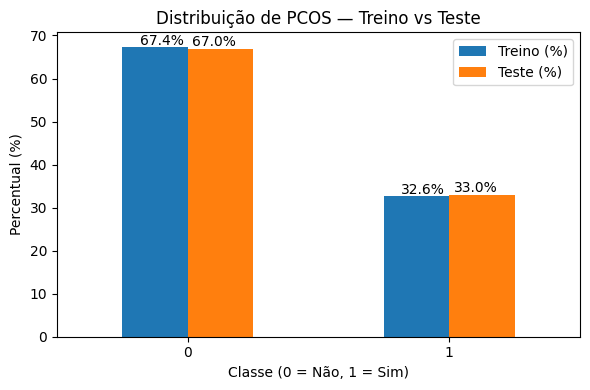

In [ ]:
X = df.drop(columns=['PCOS (Y/N)'])
y = df['PCOS (Y/N)'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Aplica o pipeline SEM VAZAMENTO: fit apenas no treino, transform em ambos
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared  = full_pipeline.transform(X_test)

print(f"Treino: {X_train_prepared.shape}  |  Teste: {X_test_prepared.shape}")

# Verificar balanceamento de classes nos dois conjuntos
train_pct = y_train.value_counts(normalize=True) * 100
test_pct  = y_test.value_counts(normalize=True) * 100
df_split = pd.DataFrame({'Treino (%)': train_pct, 'Teste (%)': test_pct}).sort_index()

ax = df_split.plot(kind='bar', figsize=(6, 4))
plt.title('Distribuição de PCOS — Treino vs Teste')
plt.xlabel('Classe (0 = Não, 1 = Sim)')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)

for i in range(len(df_split)):
    for j, col in enumerate(df_split.columns):
        v = df_split.iloc[i, j]
        plt.text(i + (j - 0.5) * 0.2, v + 0.5, f'{v:.1f}%', ha='center')

plt.legend()
plt.tight_layout()
plt.show()


## 7. Comparação de modelos — todas as features

Avaliamos três algoritmos com validação cruzada 5-fold sobre o conjunto de treino:

| Modelo | Motivação |
|---|---|
| **Regressão Logística** | Baseline linear interpretável |
| **Random Forest** | Ensemble de árvores, robusto a não-linearidades |
| **XGBoost** | Gradient boosting regularizado, geralmente top performer |

Métricas avaliadas: ROC AUC, F1-score, Precision e Accuracy.


In [ ]:
# Definição central dos modelos — reutilizada em todas as seções seguintes
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost':             XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3,
        subsample=0.7, colsample_bytree=0.7,
        random_state=42, eval_metric='logloss',
    ),
}

print("=" * 60)
print("CROSS-VALIDATION (5-fold) — TODAS AS FEATURES")
print("=" * 60)

resultados_cv = comparar_modelos(modelos, full_pipeline, X_train, y_train)


CROSS-VALIDATION (5-fold) — TODAS AS FEATURES

📊 Logistic Regression
  ROC AUC (val):   0.9281
  ROC AUC (train): 0.9768
  Gap overfitting: 0.0488  🟢
  Recall:          0.8579
  F1-score:        0.8029
  Precision:       0.7582
  Accuracy:        0.8634

📊 Random Forest
  ROC AUC (val):   0.9510
  ROC AUC (train): 1.0000
  Gap overfitting: 0.0490  🟢
  Recall:          0.7581
  F1-score:        0.8132
  Precision:       0.8798
  Accuracy:        0.8889

📊 XGBoost
  ROC AUC (val):   0.9421
  ROC AUC (train): 1.0000
  Gap overfitting: 0.0579  🟡
  Recall:          0.7650
  F1-score:        0.8019
  Precision:       0.8487
  Accuracy:        0.8797


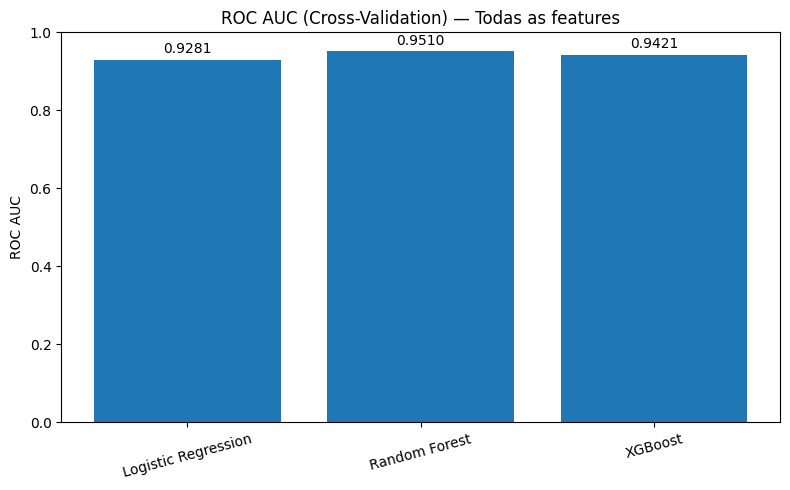

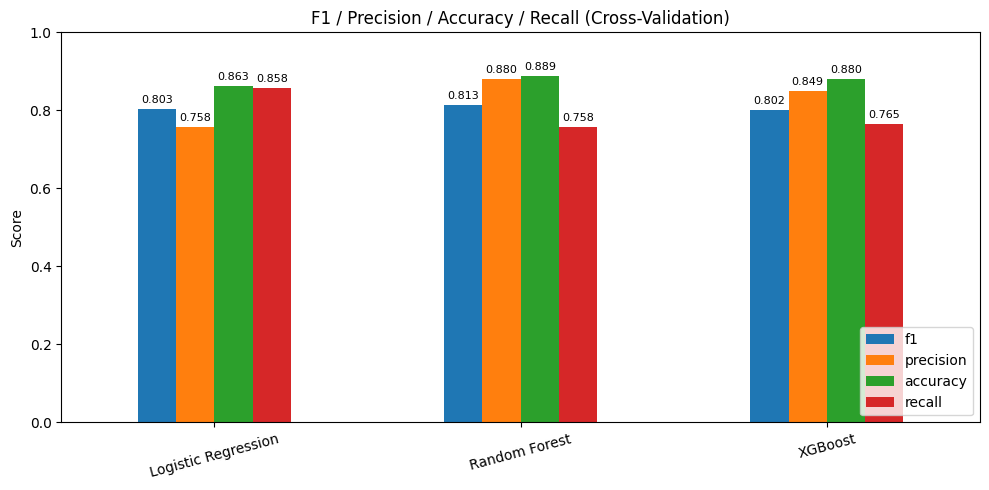


🏆 Ranking por ROC AUC:
                      roc_auc        f1 precision  accuracy    recall
Random Forest        0.951013  0.813175  0.879766  0.888933  0.758128
XGBoost               0.94213  0.801869   0.84871  0.879685  0.765025
Logistic Regression  0.928081  0.802895  0.758223  0.863406  0.857882


In [ ]:
# Visualização comparativa das métricas
df_cv = pd.DataFrame(resultados_cv).T

# ── ROC AUC ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_cv.index, df_cv['roc_auc'])
ax.set_title('ROC AUC (Cross-Validation) — Todas as features')
ax.set_ylabel('ROC AUC')
ax.set_ylim(0, 1)
ax.set_xticks(range(len(df_cv)))
ax.set_xticklabels(df_cv.index, rotation=15)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{b.get_height():.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# ── F1, Precision, Accuracy ───────────────────────────────
ax2 = df_cv[['f1', 'precision', 'accuracy','recall']].plot(kind='bar', figsize=(10, 5))
plt.title('F1 / Precision / Accuracy / Recall (Cross-Validation)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
for p in ax2.patches:
    ax2.text(p.get_x() + p.get_width()/2, p.get_height() + 0.01,
             f'{p.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print("\n🏆 Ranking por ROC AUC:")
print(df_cv.sort_values('roc_auc', ascending=False)[['roc_auc', 'f1', 'precision', 'accuracy', 'recall']].to_string())


## 8. Análise de overfitting (Gap Treino vs Validação)

O gap entre o desempenho no treino e na validação é um indicador de overfitting:

- **Gap > 10%** 🔴 → overfitting forte — considerar regularização ou redução de complexidade  
- **Gap 5–10%** 🟡 → overfitting moderado — monitorar  
- **Gap < 5%**  🟢 → generalização adequada


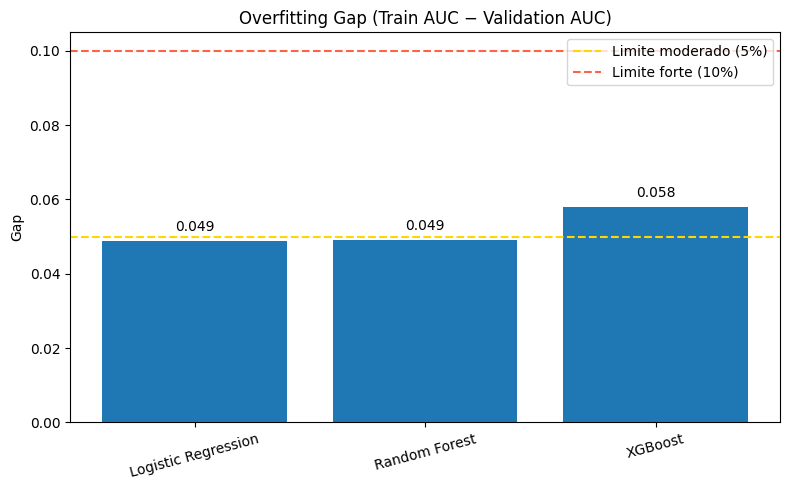

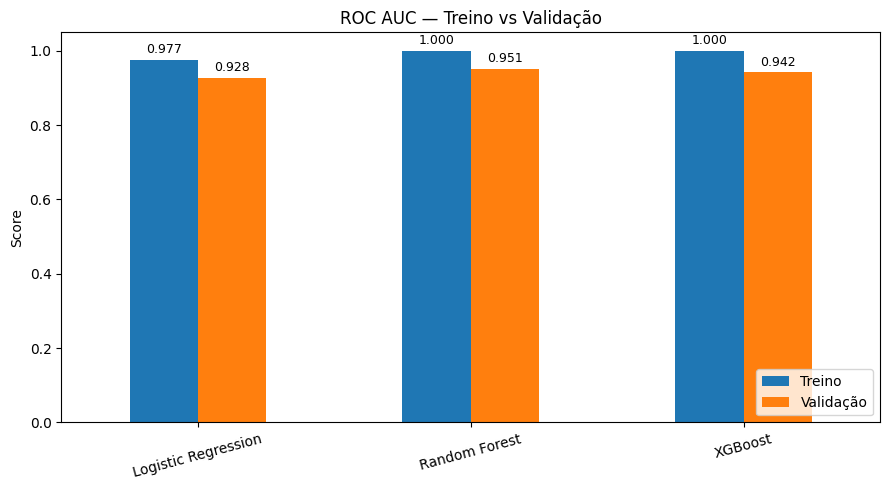

In [ ]:
df_gap = pd.DataFrame({
    nome: {'train': v['train_auc'], 'val': v['roc_auc'], 'gap': v['gap']}
    for nome, v in resultados_cv.items()
}).T

# ── Gap absoluto ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_gap.index, df_gap['gap'])
ax.set_title('Overfitting Gap (Train AUC − Validation AUC)')
ax.set_ylabel('Gap')
ax.axhline(0.05, color='gold',   linestyle='--', label='Limite moderado (5%)')
ax.axhline(0.10, color='tomato', linestyle='--', label='Limite forte (10%)')
ax.set_xticks(range(len(df_gap)))
ax.set_xticklabels(df_gap.index, rotation=15)
ax.legend()
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.002,
            f'{b.get_height():.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# ── Train vs Validation side-by-side ─────────────────────
ax2 = df_gap[['train', 'val']].plot(kind='bar', figsize=(9, 5))
plt.title('ROC AUC — Treino vs Validação')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(['Treino', 'Validação'], loc='lower right')
for p in ax2.patches:
    ax2.text(p.get_x() + p.get_width()/2, p.get_height() + 0.01,
             f'{p.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


## 9. Curva ROC no Test Set — todas as features

Treinamos cada modelo no conjunto de treino completo e avaliamos no test set
(dados que o modelo nunca viu durante cross-validation).


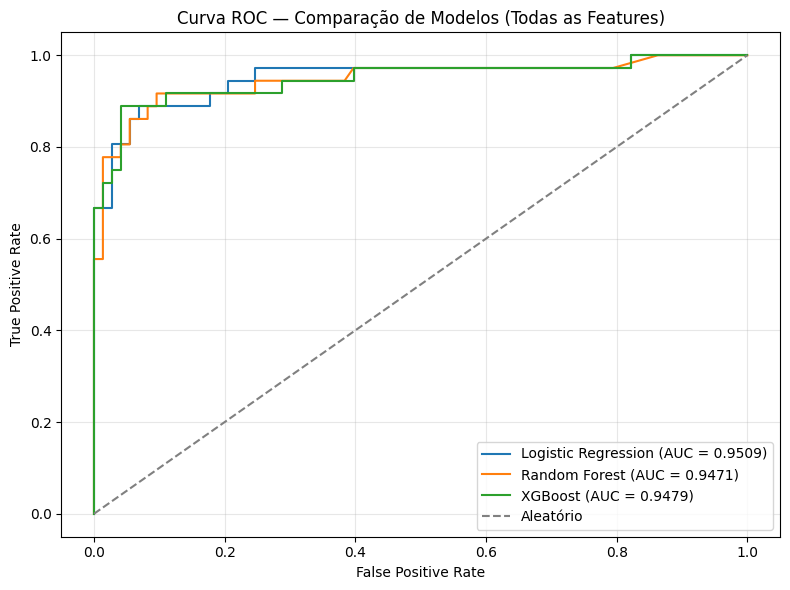


Métricas no Test Set (todas as features):
                     roc_auc      f1  precision  accuracy  recall
Logistic Regression   0.9509  0.8312     0.7805    0.8807  0.8889
Random Forest         0.9471  0.8485     0.9333    0.9083  0.7778
XGBoost               0.9479  0.8696     0.9091    0.9174  0.8333


In [ ]:
plt.figure(figsize=(8, 6))

resultados_teste_all = {}

for nome, modelo in modelos.items():
    pipe = Pipeline([
        ('preprocessor', full_pipeline),
        ('model', modelo),
    ])
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred  = pipe.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    resultados_teste_all[nome] = {
        'roc_auc':  auc,
        'f1':       f1_score(y_test, y_pred),
        'precision':precision_score(y_test, y_pred),
        'accuracy': accuracy_score(y_test, y_pred),
        'recall':   recall_score(y_test, y_pred),
    }

    plt.plot(fpr, tpr, label=f"{nome} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório')
plt.title('Curva ROC — Comparação de Modelos (Todas as Features)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMétricas no Test Set (todas as features):")
print(pd.DataFrame(resultados_teste_all).T.round(4).to_string())


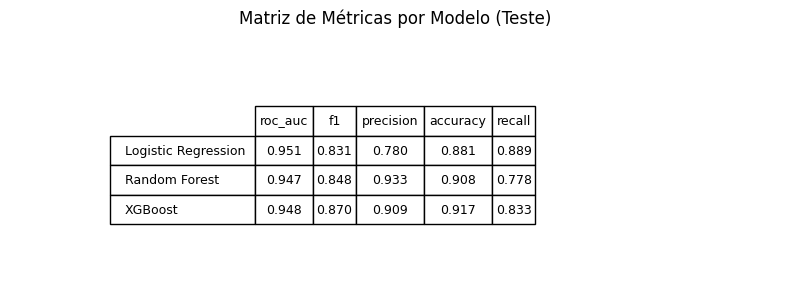

In [ ]:
#Aplicação na base de teste
df_matriz = pd.DataFrame(resultados_teste_all).T

df_formatado = df_matriz.copy()

for col in df_formatado.columns:
    df_formatado[col] = df_formatado[col].apply(lambda x: f"{x:.3f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

tabela = ax.table(
    cellText=df_formatado.values,
    colLabels=df_formatado.columns,
    rowLabels=df_formatado.index,
    loc='center',
    cellLoc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.2, 1.8)

for i in range(len(df_formatado.columns)):
    tabela.auto_set_column_width(i)

plt.title("Matriz de Métricas por Modelo (Teste)", pad=20)

plt.tight_layout()
plt.savefig("matriz_metricas.png", dpi=300, bbox_inches='tight')

plt.show()

## 10. Seleção das Top 20 features

Estratégia de seleção por correlação absoluta com o target.
O objetivo é verificar se um subconjunto reduzido de features mantém
(ou supera) o desempenho dos modelos com todas as features.


### 10.1 Seleção das features

In [ ]:
corr_top20 = df.corr(numeric_only=True)['PCOS (Y/N)'].abs().sort_values(ascending=False)
top20_features = corr_top20.drop('PCOS (Y/N)').head(20).index.tolist()

print('Top 20 features selecionadas por |correlação| com PCOS:')
for i, feat in enumerate(top20_features, 1):
    print(f"  {i:2d}. {feat:<40s}  |corr| = {corr_top20[feat]:.4f}")


Top 20 features selecionadas por |correlação| com PCOS:
   1. Follicle No. (R)                          |corr| = 0.6483
   2. Follicle No. (L)                          |corr| = 0.6033
   3. Skin darkening (Y/N)                      |corr| = 0.4757
   4. hair growth(Y/N)                          |corr| = 0.4647
   5. Weight gain(Y/N)                          |corr| = 0.4410
   6. Cycle(R/I)                                |corr| = 0.4016
   7. Fast food (Y/N)                           |corr| = 0.3762
   8. Pimples(Y/N)                              |corr| = 0.2861
   9. AMH(ng/mL)                                |corr| = 0.2641
  10. BMI                                       |corr| = 0.1995
  11. Cycle length(days)                        |corr| = 0.1785
  12. Hair loss(Y/N)                            |corr| = 0.1729
  13.  Age (yrs)                                |corr| = 0.1685
  14. Hip(inch)                                 |corr| = 0.1623
  15. Avg. F size (L) (mm)                      

### 10.2 Split e pipeline para as Top 20

In [ ]:
X_top20 = df[top20_features]
y_top20 = df['PCOS (Y/N)'].astype(int)

X_train_t20, X_test_t20, y_train_t20, y_test_t20 = train_test_split(
    X_top20, y_top20, test_size=0.2, random_state=42, stratify=y_top20
)
print(f"Treino: {X_train_t20.shape}  |  Teste: {X_test_t20.shape}")

# Separa binárias e numéricas dentro do top20
binary_cols_all = [
    'Pregnant(Y/N)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
    'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
    'Fast food (Y/N)', 'Reg.Exercise(Y/N)',
    'Blood Group_12', 'Blood Group_13', 'Blood Group_14',
    'Blood Group_15', 'Blood Group_16', 'Blood Group_17', 'Blood Group_18',
]

binary_cols_t20 = [c for c in top20_features if c in binary_cols_all]
num_cols_t20    = [c for c in top20_features if c not in binary_cols_all]

num_pipeline_t20 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

full_pipeline_t20 = ColumnTransformer([
    ('num', num_pipeline_t20, num_cols_t20),
    ('bin', 'passthrough',    binary_cols_t20),
])

print(f"\nNuméricas no top20 ({len(num_cols_t20)}): {num_cols_t20}")
print(f"Binárias no top20  ({len(binary_cols_t20)}): {binary_cols_t20}")


Treino: (432, 20)  |  Teste: (109, 20)

Numéricas no top20 (14): ['Follicle No. (R)', 'Follicle No. (L)', 'Cycle(R/I)', 'AMH(ng/mL)', 'BMI', 'Cycle length(days)', ' Age (yrs)', 'Hip(inch)', 'Avg. F size (L) (mm)', 'Marraige Status (Yrs)', 'Endometrium (mm)', 'Avg. F size (R) (mm)', 'Pulse rate(bpm) ', 'Hb(g/dl)']
Binárias no top20  (6): ['Skin darkening (Y/N)', 'hair growth(Y/N)', 'Weight gain(Y/N)', 'Fast food (Y/N)', 'Pimples(Y/N)', 'Hair loss(Y/N)']


### 10.3 Cross-Validation 5-fold — Top 20 features

In [ ]:
print("=" * 60)
print("CROSS-VALIDATION (5-fold) — TOP 20 FEATURES")
print("=" * 60)

resultados_t20_cv = comparar_modelos(modelos, full_pipeline_t20, X_train_t20, y_train_t20)


CROSS-VALIDATION (5-fold) — TOP 20 FEATURES

📊 Logistic Regression
  ROC AUC (val):   0.9461
  ROC AUC (train): 0.9698
  Gap overfitting: 0.0237  🟢
  Recall:          0.8788
  F1-score:        0.8171
  Precision:       0.7649
  Accuracy:        0.8727

📊 Random Forest
  ROC AUC (val):   0.9488
  ROC AUC (train): 1.0000
  Gap overfitting: 0.0512  🟡
  Recall:          0.7650
  F1-score:        0.8021
  Precision:       0.8463
  Accuracy:        0.8797

📊 XGBoost
  ROC AUC (val):   0.9417
  ROC AUC (train): 0.9998
  Gap overfitting: 0.0581  🟡
  Recall:          0.7865
  F1-score:        0.8098
  Precision:       0.8374
  Accuracy:        0.8819


### 10.4 Avaliação no Test Set — Top 20 features

In [ ]:
resultados_t20_tst = {}

print("=" * 60)
print("AVALIAÇÃO NO TEST SET — TOP 20 FEATURES")
print("=" * 60)

for nome, modelo in modelos.items():
    pipe = Pipeline([
        ('preprocessor', full_pipeline_t20),
        ('model', modelo),
    ])
    pipe.fit(X_train_t20, y_train_t20)
    y_pred  = pipe.predict(X_test_t20)
    y_proba = pipe.predict_proba(X_test_t20)[:, 1]

    resultados_t20_tst[nome] = {
        'roc_auc':   roc_auc_score(y_test_t20, y_proba),
        'f1':        f1_score(y_test_t20, y_pred),
        'precision': precision_score(y_test_t20, y_pred),
        'accuracy':  accuracy_score(y_test_t20, y_pred),
        'recall':    recall_score(y_test_t20, y_pred),
    }

    print(f"\n{nome}")
    for metric, val in resultados_t20_tst[nome].items():
        print(f"  {metric:<12}: {val:.4f}")
    print(classification_report(y_test_t20, y_pred))


AVALIAÇÃO NO TEST SET — TOP 20 FEATURES

Logistic Regression
  roc_auc     : 0.9513
  f1          : 0.8684
  precision   : 0.8250
  accuracy    : 0.9083
  recall      : 0.9167
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        73
           1       0.82      0.92      0.87        36

    accuracy                           0.91       109
   macro avg       0.89      0.91      0.90       109
weighted avg       0.91      0.91      0.91       109


Random Forest
  roc_auc     : 0.9462
  f1          : 0.8824
  precision   : 0.9375
  accuracy    : 0.9266
  recall      : 0.8333
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        73
           1       0.94      0.83      0.88        36

    accuracy                           0.93       109
   macro avg       0.93      0.90      0.91       109
weighted avg       0.93      0.93      0.93       109


XGBoost
  roc_auc     : 0.9456
  f1    

Matriz com as Métricas do top20

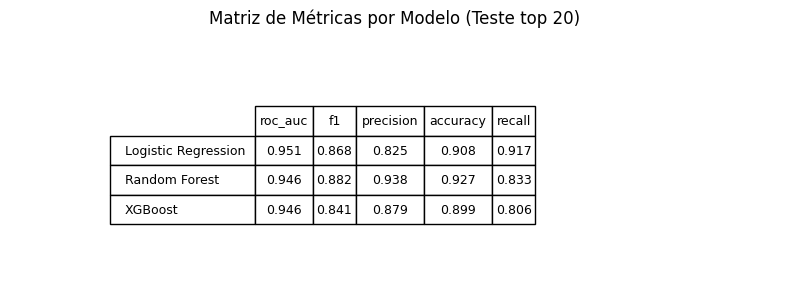

In [ ]:
df_matriz = pd.DataFrame(resultados_t20_tst).T

df_formatado = df_matriz.copy()

for col in df_formatado.columns:
    df_formatado[col] = df_formatado[col].apply(lambda x: f"{x:.3f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

tabela = ax.table(
    cellText=df_formatado.values,
    colLabels=df_formatado.columns,
    rowLabels=df_formatado.index,
    loc='center',
    cellLoc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.2, 1.8)

for i in range(len(df_formatado.columns)):
    tabela.auto_set_column_width(i)

plt.title("Matriz de Métricas por Modelo (Teste top 20)", pad=20)

plt.tight_layout()
plt.savefig("matriz_metricas.png", dpi=300, bbox_inches='tight')

plt.show()

### 10.5 Comparação: Todas as features vs. Top 20

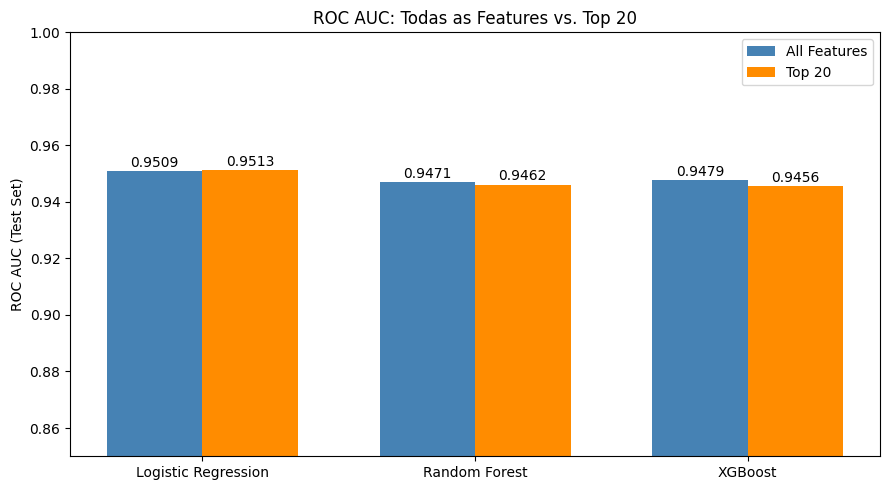


Modelo                      All Features     Top 20     Delta
--------------------------------------------------------------
Logistic Regression               0.9509     0.9513  ↑ 0.0004
Random Forest                     0.9471     0.9462  ↓ 0.0010
XGBoost                           0.9479     0.9456  ↓ 0.0023


In [ ]:

modelos_names = list(modelos.keys())
auc_all = [resultados_teste_all[n]['roc_auc'] for n in modelos_names]
auc_t20 = [resultados_t20_tst[n]['roc_auc']   for n in modelos_names]

x     = np.arange(len(modelos_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, auc_all, width, label='All Features',  color='steelblue')
bars2 = ax.bar(x + width/2, auc_t20, width, label='Top 20',        color='darkorange')

ax.set_ylabel('ROC AUC (Test Set)')
ax.set_title('ROC AUC: Todas as Features vs. Top 20')
ax.set_xticks(x)
ax.set_xticklabels(modelos_names)
ax.set_ylim(0.85, 1.0)
ax.legend()

for b in list(bars1) + list(bars2):
    ax.annotate(f'{b.get_height():.4f}',
                xy=(b.get_x() + b.get_width()/2, b.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center')

plt.tight_layout()
plt.show()

# Ranking textual com delta
print(f"\n{'Modelo':<25} {'All Features':>14} {'Top 20':>10} {'Delta':>9}")
print('-' * 62)
for n in modelos_names:
    a = resultados_teste_all[n]['roc_auc']
    t = resultados_t20_tst[n]['roc_auc']
    d = t - a
    arrow = '↑' if d > 0 else ('↓' if d < 0 else '=')
    print(f"{n:<25} {a:>14.4f} {t:>10.4f}  {arrow} {abs(d):.4f}")


## 11. Explicabilidade — SHAP (Regressão Logística)

SHAP (SHapley Additive exPlanations) quantifica a contribuição individual de
cada feature para cada predição do modelo.

Usamos `LinearExplainer`, otimizado para modelos lineares como a Regressão Logística.
O gráfico *summary plot* mostra:

- **Eixo X:** valor SHAP — magnitude e direção do impacto na predição  
- **Cor:** valor real da feature (vermelho = alto, azul = baixo)  
- **Ordem:** features mais impactantes no topo


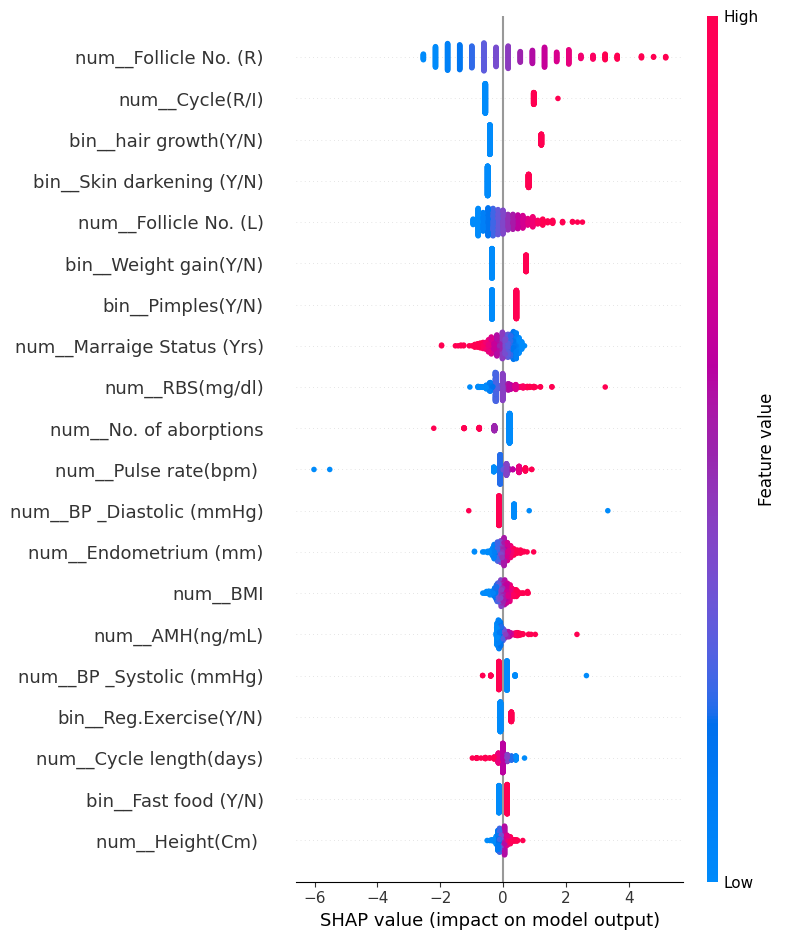

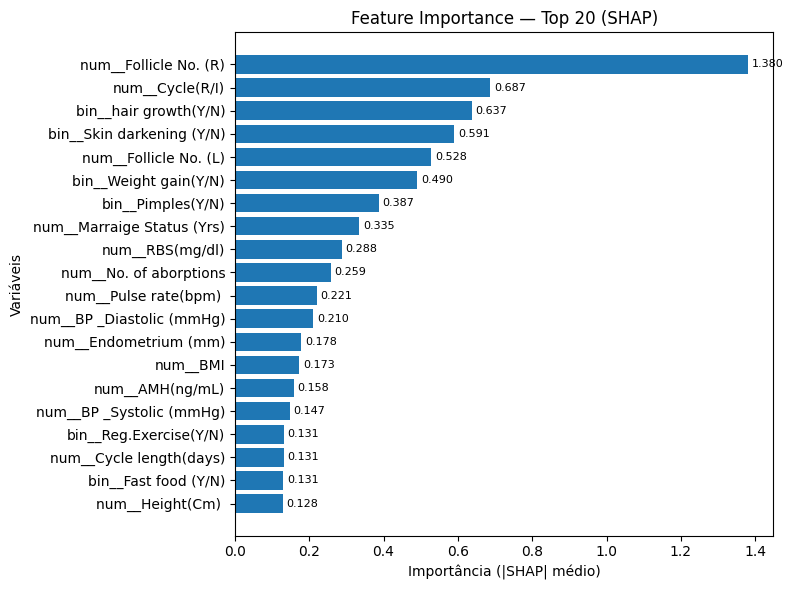

In [ ]:
# Treinar modelo final (Regressão Logística com todas as features)
pipeline_final = Pipeline([
    ('preprocessor', full_pipeline),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced')),
])
pipeline_final.fit(X_train, y_train)

# Transformar dados de treino para alimentar o explainer
X_train_transformed = pipeline_final.named_steps['preprocessor'].transform(X_train)

# Nomes das features após o ColumnTransformer
feature_names = pipeline_final.named_steps['preprocessor'].get_feature_names_out()

# LinearExplainer é o mais adequado para Regressão Logística:
# usa a média como baseline e calcula contribuições lineares exatas
explainer   = shap.LinearExplainer(
    pipeline_final.named_steps['model'],
    X_train_transformed,
    feature_names=feature_names,
)
shap_values = explainer(X_train_transformed)

# ── Summary plot: Top 20 features mais impactantes ───────
plt.figure()
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    max_display=20,
)

# ── Ranking numérico de importância global ────────────────
shap_importance = (
    pd.DataFrame({
        'feature':    feature_names,
        'importance': np.abs(shap_values.values).mean(axis=0),
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

# ── Gráfico de Feature Importance (Top 20) ────────────────
top20 = shap_importance.head(20)

plt.figure(figsize=(8,6))
bars = plt.barh(top20['feature'][::-1], top20['importance'][::-1])

plt.xlabel("Importância (|SHAP| médio)")
plt.ylabel("Variáveis")
plt.title("Feature Importance — Top 20 (SHAP)")

# Rótulos nas barras
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va='center',
        fontsize=8
    )

plt.tight_layout()
plt.show()

Os dois gráficos de SHAP deixam bem claro que o modelo está apostando em sinais clássicos de PCOS para tomar suas decisões, o que é ótimo para explicarmos os resultados. O gráfico de barras mostra que o número de folículos, ciclo irregular, crescimento de pelos e escurecimento da pele são as variáveis que mais pesam na previsão. Já o gráfico de pontos (beeswarm) reforça que, quanto mais altos esses valores, maior a chance do modelo apontar PCOS, e quando são baixos, a chance diminui. Ou seja, o modelo foca em fatores reconhecidos pela medicina, tornando suas decisões fáceis de entender por médicos e pacientes.